# 01 - EDA: Vaccine Sentiment Tweets
Goal: understand class balance, label reliability, length, vocabulary and word-order effects, and use them to justify preprocessing and model choices.

In [4]:
%pip install -q emoji fasttext-numpy2-wheel wordcloud
import os, sys

# Colab: mount Drive and use the project folder there. Local: use the repo root.
if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE = "/content/drive/MyDrive/formative2-vaccine-sentiment"
else:
    BASE = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

for d in ["data/raw", "data/processed", "reports/figures", "reports/predictions"]:
    os.makedirs(os.path.join(BASE, d), exist_ok=True)
os.chdir(BASE)
sys.path.insert(0, BASE)
print("Working directory:", os.getcwd())

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 4.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/formative2-vaccine-sentiment


## Data checks
Test has no labels or `agreement`, so we evaluate on our own split of `Train.csv`. A few rows have missing or odd labels or missing agreement and are dropped.

In [6]:
import re, collections, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from wordcloud import WordCloud

warnings.filterwarnings("ignore", message="This pattern is interpreted")
sns.set_theme(style="whitegrid"); pd.set_option("display.max_colwidth", 200)
FIG = "reports/figures/"
LABEL_NAMES = {-1: "negative", 0: "neutral", 1: "positive"}

df = pd.read_csv("/content/Train (1).csv"); test = pd.read_csv("/content/Test.csv")
print("Train:", df.shape, "| Test:", test.shape, "| Test columns:", list(test.columns))
print("\nMissing values:\n", df.isna().sum())
print("\nLabel values:\n", df["label"].value_counts(dropna=False))
odd = df[df["label"].isna() | ~df["label"].isin([-1, 0, 1]) | df["agreement"].isna()]
print(f"\n{len(odd)} problem rows (missing/odd label or missing agreement):"); display(odd)

# keep only valid rows for the rest of the EDA
df = df.dropna(subset=["safe_text", "label", "agreement"])
df = df[df["label"].isin([-1, 0, 1])].copy()
df["label"] = df["label"].astype(int)
df["label_name"] = df["label"].map(LABEL_NAMES)
print("\nExact duplicate tweets:", df["safe_text"].duplicated().sum())
df.head()

Train: (10001, 4) | Test: (5177, 2) | Test columns: ['tweet_id', 'safe_text']

Missing values:
 tweet_id     0
safe_text    0
label        1
agreement    2
dtype: int64

Label values:
 label
 0.000000    4908
 1.000000    4053
-1.000000    1038
 NaN            1
 0.666667       1
Name: count, dtype: int64

2 problem rows (missing/odd label or missing agreement):


,tweet_id,safe_text,label,agreement
4798,RQMQ0L2A,#lawandorderSVU,NaN,NaN
4799,I cannot believe in this day and age some parents could be so oblivious to reality as to not #vaccinate their child.,1,0.666667,NaN



Exact duplicate tweets: 343


,tweet_id,safe_text,label,agreement,label_name
0,CL1KWCMY,Me &amp; The Big Homie meanboy3000 #MEANBOY #MB #MBS #MMR #STEGMANLIFE @ Stegman St. <url>,0,1.0,neutral
1,E3303EME,I'm 100% thinking of devoting my career to proving autism isn't caused by vaccines due to the IDIOTIC posts I've seen about World Autism Day,1,1.0,positive
2,M4IVFSMS,"#whatcausesautism VACCINES, DO NOT VACCINATE YOUR CHILD",-1,1.0,negative
3,1DR6ROZ4,"I mean if they immunize my kid with something that won't secretly kill him years down the line then I'm all for it, but I don't trust that",-1,1.0,negative
4,J77ENIIE,Thanks to <user> Catch me performing at La Nuit NYC 1134 1st ave. Show starts at 6! #jennifair #mmr… <url>,0,1.0,neutral


## Class distribution
Negative ~10%, neutral ~49%, positive ~41%.
→ Macro-F1 as primary metric, stratified splits, class weighting.

label_name
negative    1038
neutral     4908
positive    4053
Name: count, dtype: int64 
 label_name
negative    10.38
neutral     49.08
positive    40.53
Name: count, dtype: float64


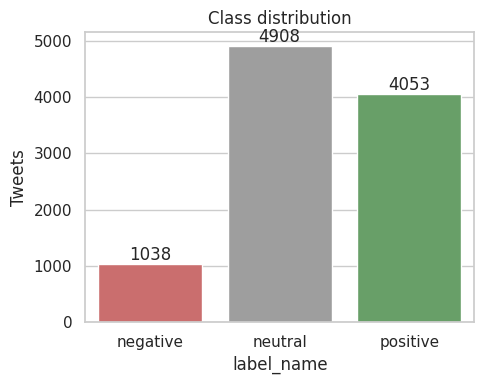

Imbalance ratio (max/min): 4.73


In [7]:
counts = df["label_name"].value_counts().reindex(["negative", "neutral", "positive"])
print(counts, "\n", (counts / len(df) * 100).round(2))
plt.figure(figsize=(5, 4))
ax = sns.barplot(x=counts.index, y=counts.values, hue=counts.index, legend=False,
                 palette=["#d95f5f", "#9e9e9e", "#5fa85f"])
for i, v in enumerate(counts.values):
    ax.text(i, v, str(v), ha="center", va="bottom")
plt.title("Class distribution"); plt.ylabel("Tweets"); plt.tight_layout()
plt.savefig(FIG + "class_distribution.png", dpi=200); plt.show()
print("Imbalance ratio (max/min):", round(counts.max() / counts.min(), 2))

## Annotator agreement
~41% of tweets are below 0.7 agreement; negative is lowest.
→ Label noise limits achievable performance; errors likely concentrate on negative tweets.

count    9999.000000
mean        0.854252
std         0.180707
min         0.333333
25%         0.666667
50%         1.000000
75%         1.000000
max         1.000000
Name: agreement, dtype: float64


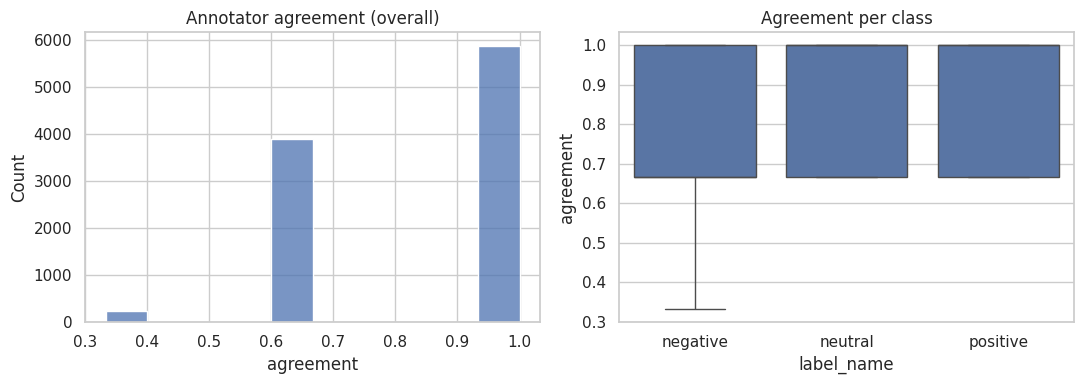

             mean  median
label_name               
negative    0.713   0.667
neutral     0.881   1.000
positive    0.858   1.000
Share with agreement < 0.7: 0.413


In [8]:
print(df["agreement"].describe())
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["agreement"], bins=10, ax=axes[0]); axes[0].set_title("Annotator agreement (overall)")
sns.boxplot(data=df, x="label_name", y="agreement", order=["negative", "neutral", "positive"], ax=axes[1])
axes[1].set_title("Agreement per class")
plt.tight_layout(); plt.savefig(FIG + "agreement.png", dpi=200); plt.show()
print(df.groupby("label_name")["agreement"].agg(["mean", "median"]).round(3))
print("Share with agreement < 0.7:", round((df["agreement"] < 0.7).mean(), 3))

## Tweet length
Mean ~16 words, 99th percentile ~27, max ~33.
→ Max sequence length of 32-35 tokens.

       n_chars  n_words
count   9999.0   9999.0
mean      99.9     16.3
std       29.9      5.3
min        3.0      1.0
50%      107.0     17.0
90%      134.0     23.0
95%      138.0     24.0
99%      140.0     27.0
max      153.0     33.0


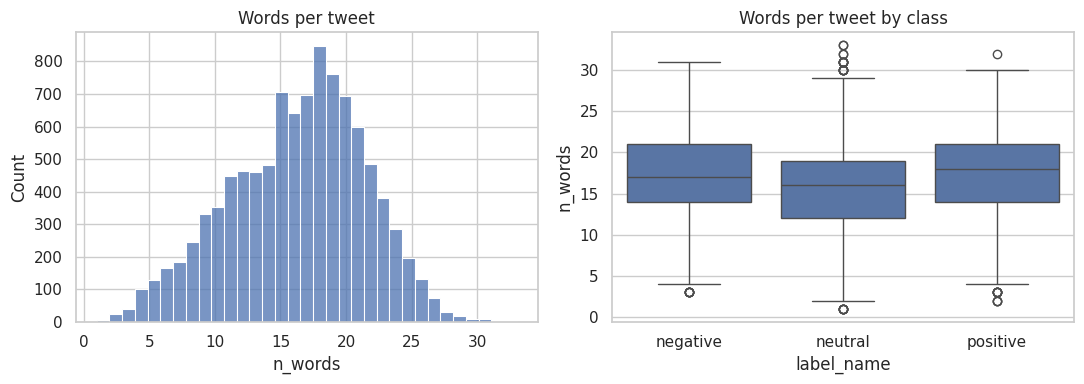

95th pct: 24 | 99th pct: 27


In [9]:
df["n_chars"] = df["safe_text"].str.len()
df["n_words"] = df["safe_text"].str.split().str.len()
print(df[["n_chars", "n_words"]].describe(percentiles=[.5, .9, .95, .99]).round(1))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["n_words"], bins=33, ax=axes[0]); axes[0].set_title("Words per tweet")
sns.boxplot(data=df, x="label_name", y="n_words", order=["negative", "neutral", "positive"], ax=axes[1])
axes[1].set_title("Words per tweet by class")
plt.tight_layout(); plt.savefig(FIG + "tweet_length.png", dpi=200); plt.show()
print("95th pct:", int(df["n_words"].quantile(.95)), "| 99th pct:", int(df["n_words"].quantile(.99)))

## Vocabulary
~68% of words appear at most twice; ~5% validation OOV rate.
→ Min-frequency cutoff, subword tokens or pretrained embeddings.

Total tokens: 163259 | Vocabulary: 13839 | Type/token: 0.0848
Appear once: 7501 (54.2%) | appear <=2 times: 9430 (68.1%)
Validation OOV token rate: 0.053


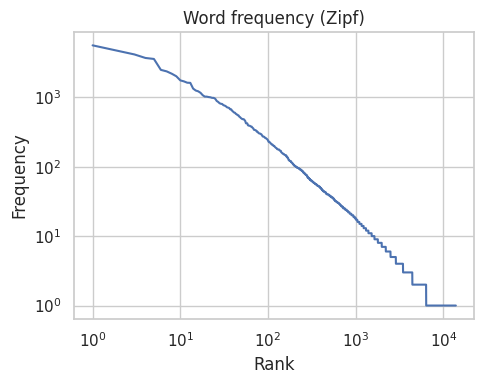

In [10]:
def simple_tokens(text):
    return re.findall(r"[a-z0-9']+", str(text).lower())

all_tokens = [t for s in df["safe_text"] for t in simple_tokens(s)]
freq = collections.Counter(all_tokens)
V = len(freq)
rare1 = sum(c == 1 for c in freq.values()); rare2 = sum(c <= 2 for c in freq.values())
print("Total tokens:", len(all_tokens), "| Vocabulary:", V, "| Type/token:", round(V / len(all_tokens), 4))
print(f"Appear once: {rare1} ({rare1/V:.1%}) | appear <=2 times: {rare2} ({rare2/V:.1%})")

tr, va = train_test_split(df, test_size=0.15, stratify=df["label"], random_state=42)
tr_vocab = {t for s in tr["safe_text"] for t in simple_tokens(s)}
va_tokens = [t for s in va["safe_text"] for t in simple_tokens(s)]
print("Validation OOV token rate:", round(np.mean([t not in tr_vocab for t in va_tokens]), 4))

vals = np.array(sorted(freq.values(), reverse=True))
plt.figure(figsize=(5, 4)); plt.loglog(np.arange(1, len(vals) + 1), vals)
plt.xlabel("Rank"); plt.ylabel("Frequency"); plt.title("Word frequency (Zipf)"); plt.tight_layout()
plt.savefig(FIG + "zipf.png", dpi=200); plt.show()

## Top words and n-grams
`<user>`/`<url>` are anonymisation placeholders (removed in cleaning). Positive and negative tweets share much of their vocabulary, so word presence alone is a weak signal.


=== NEGATIVE ===
Top words  : [('vaccines', 329), ('vaccine', 320), ('autism', 191), ('kids', 116), ('measles', 115), ('children', 105), ('amp', 89), ('vaccinations', 88), ('vaccinated', 77), ('vaccinate', 76), ('don', 73), ('cause', 70), ('cdcwhistleblower', 67), ('flu', 65), ('cdc', 63)] 
Top bigrams: [('cause autism', 37), ('vaccines cause', 34), ('flu vaccine', 34), ('vaccinate kids', 29), ('vaccine injury', 22), ('measles outbreak', 18), ('don vaccinate', 14), ('measles vaccine', 14), ('vaccines safe', 13), ('vaccinate child', 11), ('vaccine injured', 11), ('vaccine autism', 11), ('flu vaccines', 11), ('vaccinate children', 11), ('causes autism', 10)]

=== NEUTRAL ===
Top words  : [('measles', 2487), ('mmr', 823), ('health', 705), ('vaccine', 586), ('immunity', 519), ('outbreak', 392), ('cases', 323), ('people', 322), ('vaccines', 265), ('amp', 253), ('live', 229), ('disneyland', 228), ('kids', 220), ('school', 217), ('new', 214)] 
Top bigrams: [('measles outbreak', 329), ('measl

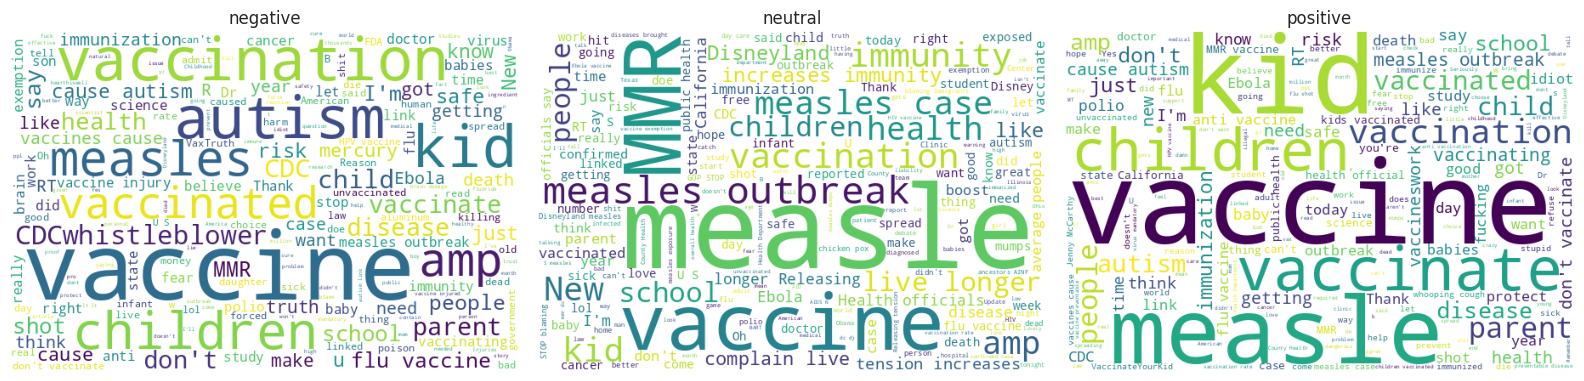

In [11]:
df["no_ph"] = df["safe_text"].str.replace(r"<(?:user|url)>", " ", regex=True, case=False)
STOP = set(CountVectorizer(stop_words="english").get_stop_words())

def top_ngrams(texts, n, k=15):
    cv = CountVectorizer(ngram_range=(n, n), stop_words="english", min_df=2)
    X = cv.fit_transform(texts); sums = np.asarray(X.sum(axis=0)).ravel()
    return [(cv.get_feature_names_out()[i], int(sums[i])) for i in sums.argsort()[::-1][:k]]

for name in ["negative", "neutral", "positive"]:
    t = df.loc[df["label_name"] == name, "no_ph"]
    print(f"\n=== {name.upper()} ===\nTop words  :", top_ngrams(t, 1), "\nTop bigrams:", top_ngrams(t, 2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, name in zip(axes, ["negative", "neutral", "positive"]):
    wc = WordCloud(width=600, height=400, background_color="white", stopwords=STOP).generate(
        " ".join(df.loc[df["label_name"] == name, "no_ph"]))
    ax.imshow(wc); ax.axis("off"); ax.set_title(name)
plt.tight_layout(); plt.savefig(FIG + "wordclouds.png", dpi=200); plt.show()

## Noise
Hashtags (~27%), all-caps (~24%) and repeated characters (~15%) are common. Cleaning keeps hashtag words, converts emojis to text, collapses repeats and keeps ! and ?.

hashtags              26.60
<user> placeholder    40.38
<url> placeholder     43.71
retweets (RT)          0.68
emojis                 5.08
repeated chars        14.68
all-caps word         24.48
exclamation           13.34
question mark         12.35
Name: % of tweets, dtype: float64

Per class (%):
 label_name          negative  neutral  positive
hashtags                28.0     26.1      26.9
<user> placeholder      54.3     38.2      39.5
<url> placeholder       39.6     48.6      38.9
retweets (RT)            0.7      0.6       0.8
emojis                   2.5      6.5       4.0
repeated chars          10.8     17.2      12.6
all-caps word           25.7     27.4      20.7
exclamation             12.9     10.9      16.5
question mark           17.6     11.5      12.0


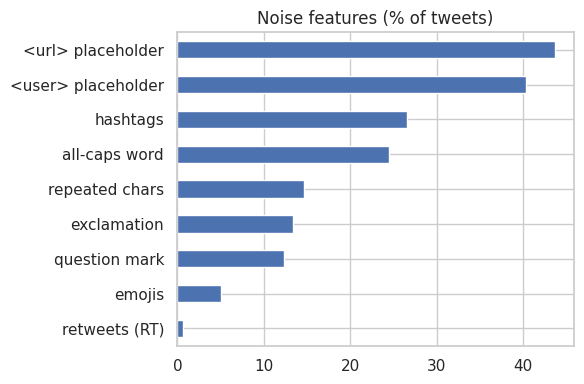

In [12]:
s = df["safe_text"]
noise = pd.DataFrame({
    "hashtags": s.str.contains(r"#\w+"),
    "<user> placeholder": s.str.contains("<user>"),
    "<url> placeholder": s.str.contains("<url>"),
    "retweets (RT)": s.str.match(r"^\s*RT\b"),
    "emojis": s.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]"),
    "repeated chars": s.str.contains(r"(.)\1{2,}"),
    "all-caps word": s.str.contains(r"\b[A-Z]{3,}\b"),
    "exclamation": s.str.contains("!"),
    "question mark": s.str.contains(r"\?"),
})
summary = noise.mean().mul(100).round(2).rename("% of tweets")
print(summary); print("\nPer class (%):\n", noise.groupby(df["label_name"]).mean().mul(100).round(1).T)
summary.sort_values().plot.barh(figsize=(6, 4), title="Noise features (% of tweets)")
plt.tight_layout(); plt.savefig(FIG + "noise_features.png", dpi=200); plt.show()

## Duplicates
Some exact and normalised duplicates, some with conflicting labels.
→ Deduplicate on cleaned text before splitting.

In [13]:
def norm(t):
    t = re.sub(r"^\s*rt\s+", "", str(t), flags=re.I)
    t = re.sub(r"<(?:user|url)>|http\S+|@\w+", " ", t.lower())
    return " ".join(re.sub(r"[^a-z0-9 ]", " ", t).split())

df["norm"] = df["safe_text"].apply(norm)
print("Exact duplicates     :", df["safe_text"].duplicated().sum())
print("Normalised duplicates:", df["norm"].duplicated().sum())
print("Duplicate texts with conflicting labels:", int((df.groupby("norm")["label"].nunique() > 1).sum()))

Exact duplicates     : 343
Normalised duplicates: 468
Duplicate texts with conflicting labels: 44


## Negation and word order
~23% of tweets contain negation, ~31% in both positive and negative classes. Identical phrasing can express opposite stances.
→ Word order and context matter, which motivates sequential models.

In [14]:
neg_pat = r"\b(?:not|no|never|don't|dont|doesn't|isn't|won't|can't|without)\b"
has_neg = df["safe_text"].str.lower().str.contains(neg_pat)
print("Tweets with negation:", round(has_neg.mean() * 100, 1), "%")
print("Share of each class with negation (%):\n", (has_neg.groupby(df["label_name"]).mean() * 100).round(1))
for name in ["negative", "neutral", "positive"]:
    sub = df[has_neg & (df["label_name"] == name)]["safe_text"]
    print(f"\n--- {name} with negation ---")
    print(sub.sample(min(4, len(sub)), random_state=1).to_string(index=False))

Tweets with negation: 23.4 %
Share of each class with negation (%):
 label_name
negative    30.9
neutral     14.8
positive    31.9
Name: safe_text, dtype: float64

--- negative with negation ---
Toni Bark: not all children respond well to vaccinations #nosb277 #noforcedvaccines Ca Legislators bought <url>
                                     I probably won't vaccinate my kids either to be real. That shit is a joke.
                                           So autism is comin from doctors vaccines .. I'm not surprised at all
“<user> How safe is the meningitis vaccine that hasn't been approved in the U.S.? <url> Scary, not far from us.

--- neutral with negation ---
Back-to-school: To vaccinate or not to vaccinate: The debate over vaccinations still lingers as Colorado kids get… <url>
          “<user> Can there be a feelings vaccine? That's one disease I never want to fucking catch.” OMG FOREAL THOUGH.
                                                                                    

## Summary of modelling decisions
| Finding | Decision |
|---|---|
| Imbalanced classes (~4.7x) | Macro-F1, stratified splits, class weighting |
| ~41% of labels below 0.7 agreement | Expect a performance ceiling; analyse errors by agreement |
| Short tweets (max ~33 words) | Max sequence length 32-35 |
| ~68% of vocab appears at most twice | Min-frequency cutoff, subword tokens or pretrained embeddings |
| `<user>` / `<url>` placeholders dominate counts | Remove during cleaning |
| Shared vocabulary; negation in ~31% of both classes | Sequential models for context |
| Duplicates, some with conflicting labels | Deduplicate before splitting |